<a href="https://colab.research.google.com/github/melia1702/Pertemuan-kelimabelas/blob/main/PRAKTIKUM_15_1_MG_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

COMPUTER VISION: OBJECT DETECTION WITH YOLO


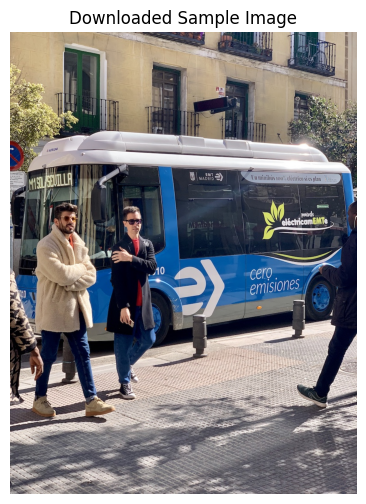

Sample image downloaded successfully


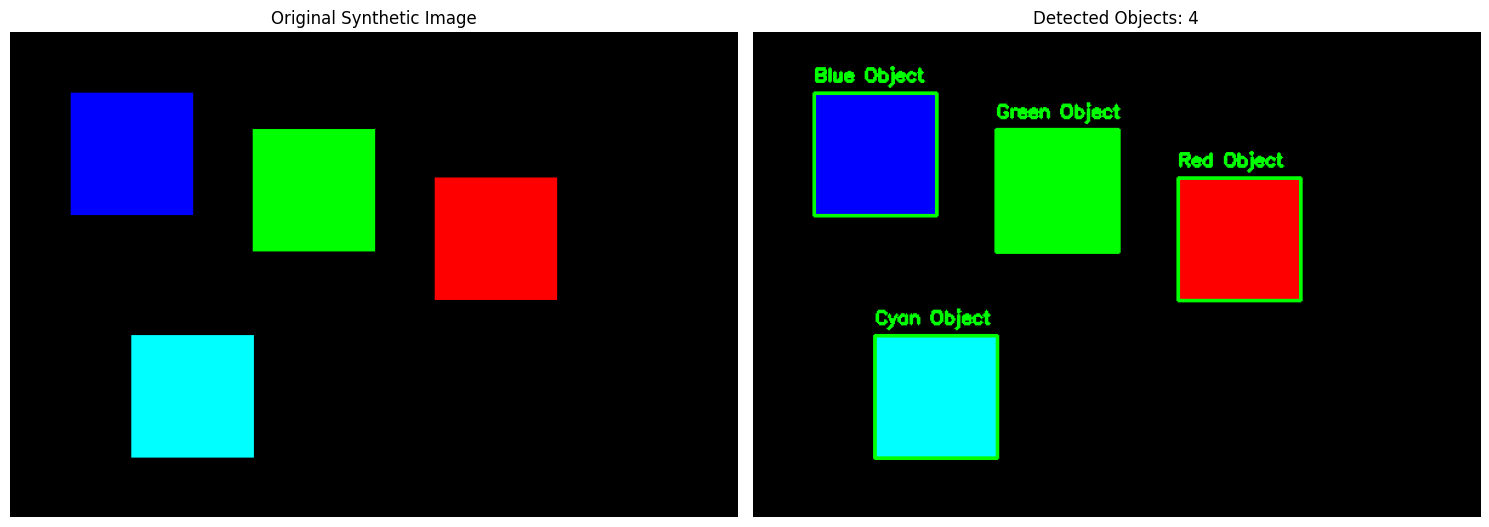


Detected 4 objects


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image


print("COMPUTER VISION: OBJECT DETECTION WITH YOLO")
print("=" * 50)


# =========================
# Download sample image
# =========================
def download_sample_image():
    url = "https://github.com/ultralytics/yolov5/raw/master/data/images/bus.jpg"

    response = requests.get(url)
    img = Image.open(BytesIO(response.content))

    return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)


# =========================
# Simulated Object Detection
# =========================
def simulate_object_detection():

    # Create synthetic image
    image = np.zeros((400, 600, 3), dtype=np.uint8)

    # Draw objects
    cv2.rectangle(image, (50, 50), (150, 150), (255, 0, 0), -1)
    cv2.rectangle(image, (200, 80), (300, 180), (0, 255, 0), -1)
    cv2.rectangle(image, (350, 120), (450, 220), (0, 0, 255), -1)
    cv2.rectangle(image, (100, 250), (200, 350), (255, 255, 0), -1)

    result_image = image.copy()

    colors = {
        'Blue Object': [255, 0, 0],
        'Green Object': [0, 255, 0],
        'Red Object': [0, 0, 255],
        'Cyan Object': [255, 255, 0]
    }

    detection_count = 0

    for label, color in colors.items():

        lower = np.array(color) - 10
        upper = np.array(color) + 10

        mask = cv2.inRange(image, lower, upper)

        contours, _ = cv2.findContours(
            mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        for contour in contours:

            if cv2.contourArea(contour) > 1000:

                x, y, w, h = cv2.boundingRect(contour)

                cv2.rectangle(
                    result_image,
                    (x, y),
                    (x + w, y + h),
                    (0, 255, 0),
                    2
                )

                cv2.putText(
                    result_image,
                    label,
                    (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0, 255, 0),
                    2
                )

                detection_count += 1

    # Display result
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax1.set_title("Original Synthetic Image")
    ax1.axis("off")

    ax2.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    ax2.set_title(f"Detected Objects: {detection_count}")
    ax2.axis("off")

    plt.tight_layout()
    plt.show()

    return result_image, detection_count


# =========================
# Main Program
# =========================
def praktikum_7_1():

    try:

        # Download image
        image = download_sample_image()

        # Show downloaded image
        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title("Downloaded Sample Image")
        plt.axis("off")
        plt.show()

        print("Sample image downloaded successfully")

        # Simulate detection
        result_image, detections = simulate_object_detection()

        print(f"\nDetected {detections} objects")

        return result_image, detections

    except Exception as e:

        print("Error:", e)

        return None, 0


# Run Program
result_image, detections = praktikum_7_1()